# ThreatMatrix — Performance Analysis


In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score,
)
warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Paths ───────────
DATASET_DIR = r"C:\Users\yuhan\Documents\UniKL\SEMESTER 6\FYP 2\threatmatrix-26\web-ids23"
BASE_OUT    = os.path.join(os.getcwd(), "threatmatrix_output")
P1_OUT      = os.path.join(BASE_OUT, "binary")
P2_OUT      = os.path.join(BASE_OUT, "multiclass")
P3_OUT      = os.path.join(BASE_OUT, "anomaly")

# ── Shared colour palette ──────────────────────────────────────────────────────
PAL_RF   = "#1565C0"   # blue   — Random Forest
PAL_XGB  = "#E65100"   # orange — XGBoost
PAL_ENS  = "#2E7D32"   # green  — Ensemble
PAL_LR   = "#6A1B9A"   # purple — LR baseline
PAL_OK   = "#2E7D32"   # high-importance / good
PAL_WARN = "#F57F17"   # mid-importance / warning
PAL_BAD  = "#C62828"   # low-importance / bad

TITLE_KW = dict(fontweight="bold")

# ── Shared ensemble weights ────────────────────────────────────────────────────
ENS_W = (0.40, 0.60)   # RF weight, XGBoost weight — same for Phase 1 and 2

print("✓ Imports complete.")
print(f"  Phase 1 artifacts : {P1_OUT}")
print(f"  Phase 2 artifacts : {P2_OUT}")
print(f"  Phase 3 artifacts : {P3_OUT}")


✓ Imports complete.
  Phase 1 artifacts : c:\Users\yuhan\Documents\UniKL\SEMESTER 6\FYP 2\threatmatrix-26\threatmatrix_output\binary
  Phase 2 artifacts : c:\Users\yuhan\Documents\UniKL\SEMESTER 6\FYP 2\threatmatrix-26\threatmatrix_output\multiclass
  Phase 3 artifacts : c:\Users\yuhan\Documents\UniKL\SEMESTER 6\FYP 2\threatmatrix-26\threatmatrix_output\anomaly


---
## Phase 1 — Benign vs Attack

This phase checks whether a given flow is normal traffic or an attack. The three models tested are Random Forest, XGBoost, and an Ensemble of both.

In [2]:
# ── Phase 1 — A: Class stub (required so joblib can unpickle model_ensemble.pkl)
class EnsembleModel:
    """Weighted soft-vote ensemble RF + XGBoost — mirrors training-script class."""
    def __init__(self, rf, xgb_clf, weights=(0.40, 0.60),
                 threshold=0.5, high_conf_min=0.70, low_conf_max=0.30):
        self.rf             = rf
        self.xgb_clf        = xgb_clf
        self.weights        = weights
        self.threshold      = threshold
        self.high_conf_min  = high_conf_min
        self.low_conf_max   = low_conf_max
        self.confidence_min = high_conf_min

    def predict_proba(self, X):
        p_rf  = self.rf.predict_proba(X)
        p_xgb = self.xgb_clf.predict_proba(X)
        return self.weights[0] * p_rf + self.weights[1] * p_xgb

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold).astype(np.int8)

    def attack_probability(self, X):
        return self.predict_proba(X)[:, 1]

    def confidence_route(self, X):
        probs  = self.attack_probability(X)
        routes = []
        for p in probs:
            if p <= self.low_conf_max:
                routes.append("BENIGN")
            elif p >= self.high_conf_min:
                routes.append("KNOWN_ATTACK")
            else:
                routes.append("UNCERTAIN")
        return routes, probs

print("✓ Phase 1 class stub defined.")


✓ Phase 1 class stub defined.


In [3]:
# ── Phase 1 — B: Load saved artifacts ────────────────────────────────────────
p1_rf      = joblib.load(os.path.join(P1_OUT, "model_rf.pkl"))
p1_xgb     = joblib.load(os.path.join(P1_OUT, "model_xgb.pkl"))
p1_ens     = joblib.load(os.path.join(P1_OUT, "model_ensemble.pkl"))
p1_scaler  = joblib.load(os.path.join(P1_OUT, "scaler.pkl"))
p1_imputer = joblib.load(os.path.join(P1_OUT, "imputer.pkl"))
p1_feats   = joblib.load(os.path.join(P1_OUT, "feature_names.pkl"))
p1_split   = np.load(os.path.join(P1_OUT, "split_indices.npz"))

with open(os.path.join(P1_OUT, "binary_metrics.json")) as f:
    p1_metrics_json = json.load(f)
p1_all_metrics = p1_metrics_json.get("models", [])

# Constants matching training script
P1_BENIGN_CAP     = 400_000
P1_ATTACK_CAP     = 200_000
P1_HIGH_CONF      = 0.70
P1_LOW_CONF       = 0.30
P1_TARGET_FILES   = {
    "web-ids23_benign.csv"             : "Benign",
    "web-ids23_portscan.csv"           : "Attack",
    "web-ids23_bruteforce_http.csv"    : "Attack",
    "web-ids23_bruteforce_https.csv"   : "Attack",
    "web-ids23_sql_injection_http.csv" : "Attack",
    "web-ids23_sql_injection_https.csv": "Attack",
}

print(f"✓ Phase 1 artifacts loaded — {len(p1_feats)} features")
print(f"  Test indices: {len(p1_split['test_idx']):,}")


✓ Phase 1 artifacts loaded — 16 features
  Test indices: 235,377


In [4]:
# ── Phase 1 — C: Reconstruct test set from CSVs + saved split indices ─────────
frames_p1 = []
for fname, lbl in P1_TARGET_FILES.items():
    path = os.path.join(DATASET_DIR, fname)
    if not os.path.exists(path):
        print(f"  [WARN] not found: {fname}")
        continue
    chunk = pd.read_csv(path, low_memory=False)
    chunk.columns = chunk.columns.str.strip()
    chunk["attack_type"] = lbl
    chunk["_src"]        = fname
    if lbl == "Benign" and len(chunk) > P1_BENIGN_CAP:
        chunk = chunk.sample(P1_BENIGN_CAP, random_state=42)
    elif lbl == "Attack" and len(chunk) > P1_ATTACK_CAP:
        chunk = chunk.sample(P1_ATTACK_CAP, random_state=42)
    frames_p1.append(chunk)

p1_df = pd.concat(frames_p1, ignore_index=True)
p1_df.drop_duplicates(inplace=True)
p1_df.reset_index(drop=True, inplace=True)

avail_p1 = [c for c in p1_feats if c in p1_df.columns]
X_p1_full = (p1_df[avail_p1]
             .replace([np.inf, -np.inf], np.nan)
             .astype(np.float32))
y_p1_full = (p1_df["attack_type"] != "Benign").astype(np.int8)
src_p1    = p1_df["_src"].values

# Apply saved imputer (no fit) then slice saved test indices
X_p1_imp = pd.DataFrame(p1_imputer.transform(X_p1_full), columns=avail_p1)
test_idx_p1  = p1_split["test_idx"]
X_test_p1    = X_p1_imp.iloc[test_idx_p1].reset_index(drop=True)
y_test_p1    = y_p1_full.iloc[test_idx_p1].to_numpy()
src_test_p1  = src_p1[test_idx_p1]
X_test_p1_sc = p1_scaler.transform(X_test_p1)

# Probabilities + predictions
rf_prob_p1   = p1_rf.predict_proba(X_test_p1_sc)[:, 1]
xgb_prob_p1  = p1_xgb.predict_proba(X_test_p1_sc)[:, 1]
ens_prob_p1  = ENS_W[0] * rf_prob_p1 + ENS_W[1] * xgb_prob_p1
rf_pred_p1   = (rf_prob_p1  >= 0.5).astype(np.int8)
xgb_pred_p1  = (xgb_prob_p1 >= 0.5).astype(np.int8)
ens_pred_p1  = (ens_prob_p1 >= 0.5).astype(np.int8)

# Rebuild metrics from predictions if JSON was empty
if not p1_all_metrics:
    def _m1(name, yp, yprob):
        return dict(name=name,
                    accuracy =accuracy_score(y_test_p1, yp),
                    precision=precision_score(y_test_p1, yp, zero_division=0),
                    recall   =recall_score(y_test_p1, yp, zero_division=0),
                    f1       =f1_score(y_test_p1, yp, zero_division=0),
                    roc_auc  =roc_auc_score(y_test_p1, yprob),
                    pr_auc   =average_precision_score(y_test_p1, yprob))
    p1_all_metrics = [
        _m1("Random Forest",       rf_pred_p1,  rf_prob_p1),
        _m1("XGBoost",             xgb_pred_p1, xgb_prob_p1),
        _m1("Ensemble (RF + XGB)", ens_pred_p1, ens_prob_p1),
    ]
    if p1_metrics_json.get("lr_baseline"):
        p1_all_metrics.append(p1_metrics_json["lr_baseline"])

b = int((y_test_p1 == 0).sum()); a = int((y_test_p1 == 1).sum())
print(f"✓ Phase 1 test set ready — {len(y_test_p1):,} rows  "
      f"Benign={b:,}  Attack={a:,}  Features={X_test_p1_sc.shape[1]}")


✓ Phase 1 test set ready — 235,377 rows  Benign=80,000  Attack=155,377  Features=16


### 1.1 Model Comparison Bar Chart

This bar chart compares all three models across six performance scores. Each group of bars represents one score, taller is better. The purple bar (LR) is a simple reference model included as a baseline, if the other models score close to it, that's a warning sign.

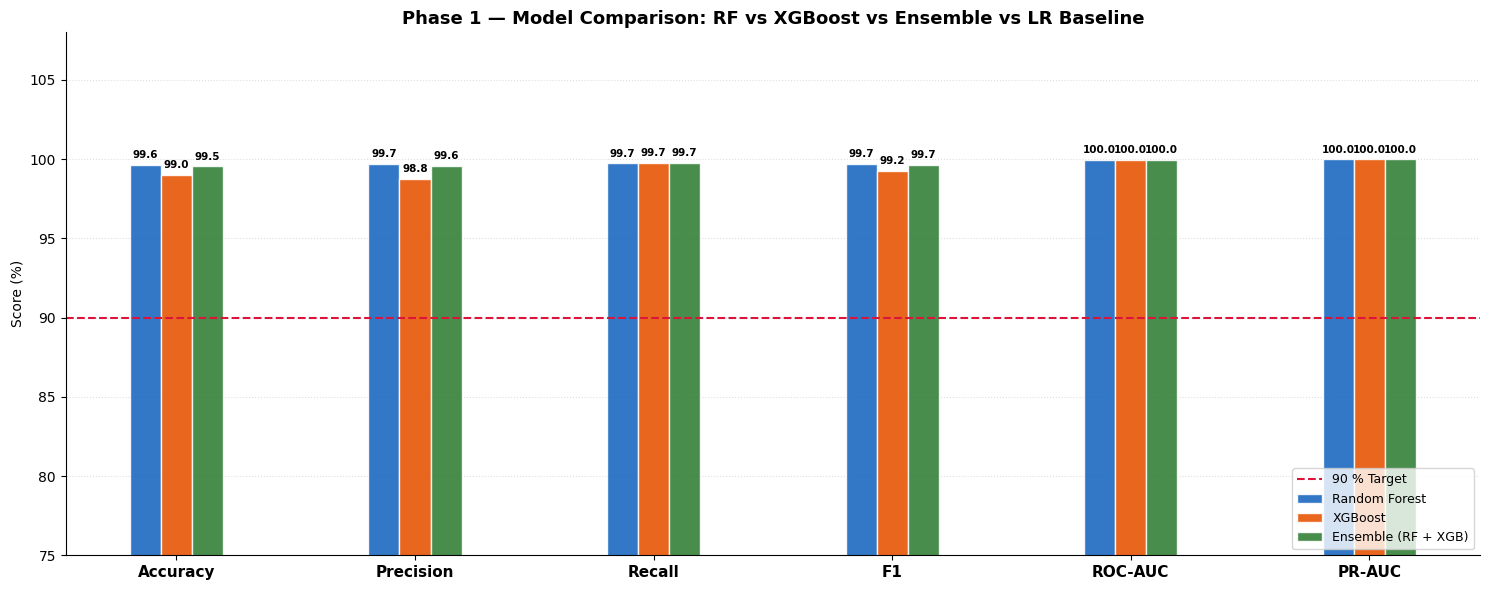

In [5]:
# ── Graph 1.1 — Model Comparison Bar Chart ────────────────────────────────────
_metric_keys   = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
_metric_labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
_model_colors  = [PAL_RF, PAL_XGB, PAL_ENS, PAL_LR]
df_m1 = pd.DataFrame(p1_all_metrics).set_index("name")[_metric_keys] * 100

fig, ax = plt.subplots(figsize=(15, 6))
n_m, w = len(df_m1), 0.13
x = np.arange(len(_metric_keys))
for i, (mname, row) in enumerate(df_m1.iterrows()):
    offset = (i - (n_m - 1) / 2) * w
    bars = ax.bar(x + offset, row.values, w, label=mname,
                  color=_model_colors[i % len(_model_colors)],
                  alpha=0.88, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                f"{h:.1f}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold")

ax.axhline(90, color="crimson", linestyle="--", lw=1.5, label="90 % Target")
ax.set_xticks(x)
ax.set_xticklabels(_metric_labels, fontsize=11, fontweight="bold")
ax.set_ylim(75, 108)
ax.set_ylabel("Score (%)")
ax.yaxis.grid(True, alpha=0.4, linestyle=":")
ax.set_title("Phase 1 — Model Comparison: RF vs XGBoost vs Ensemble vs LR Baseline",
             **TITLE_KW, fontsize=13)
ax.legend(loc="lower right", fontsize=9, frameon=True)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 1.2 ROC Curves

Each curve shows how well a model separates attacks from normal traffic. A curve that hugs the top-left corner means the model catches most attacks while keeping false alarms low. The diagonal dashed line represents a coin-flip, any model above it is doing better than random.

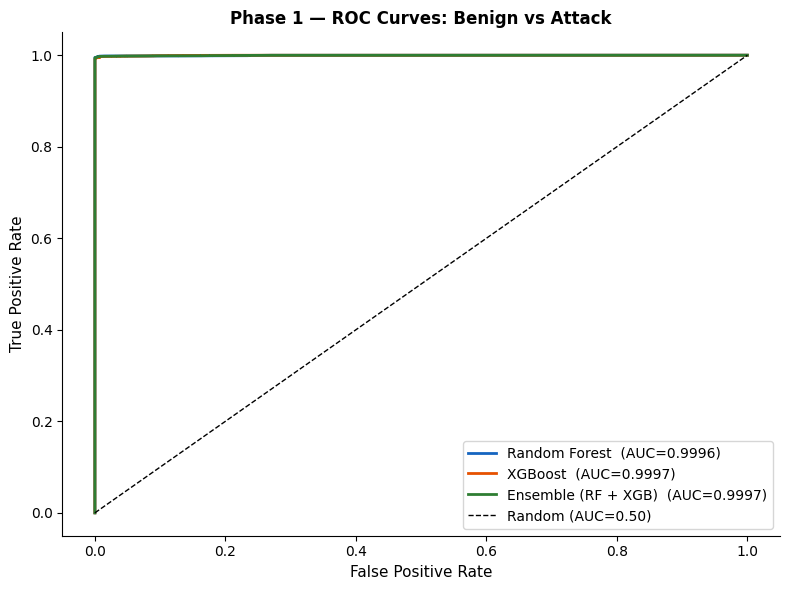

In [6]:
# ── Graph 1.2 — ROC Curves ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for (name, prob), col in zip(
    [("Random Forest", rf_prob_p1),
     ("XGBoost",       xgb_prob_p1),
     ("Ensemble (RF + XGB)", ens_prob_p1)],
    [PAL_RF, PAL_XGB, PAL_ENS]
):
    fpr, tpr, _ = roc_curve(y_test_p1, prob)
    auc = roc_auc_score(y_test_p1, prob)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{name}  (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.50)")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Phase 1 — ROC Curves: Benign vs Attack", **TITLE_KW)
ax.legend(loc="lower right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 1.3 Ensemble Confusion Matrix

This grid shows what the ensemble model predicted versus what was actually true. The top-left cell is correct normal traffic, the bottom-right is correct attacks caught. The important number is FNR (False Negative Rate) shown in the title.It tells how many real attacks the model missed.

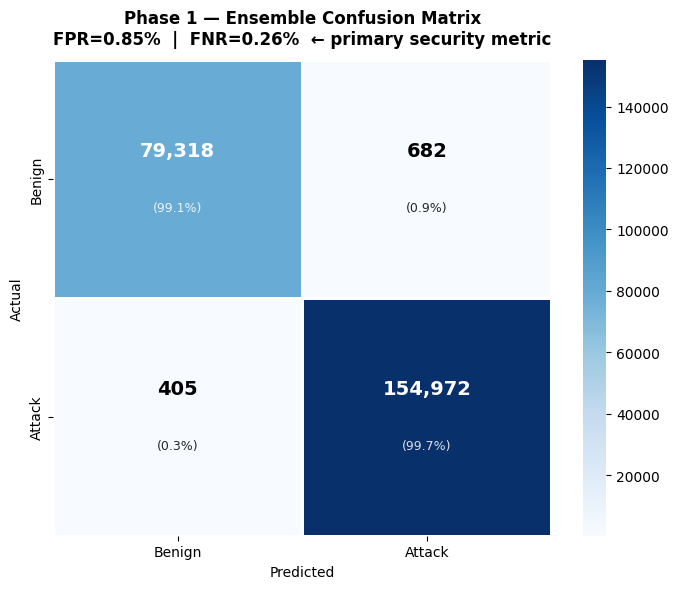

False Negative Rate: 0.26%  (405 attacks missed out of 155,377 total attacks)


In [7]:
# ── Graph 1.3 — Ensemble Confusion Matrix (raw counts + row %) ────────────────
cm_p1     = confusion_matrix(y_test_p1, ens_pred_p1)
cm_p1_pct = cm_p1.astype(float) / cm_p1.sum(axis=1, keepdims=True) * 100
tn, fp, fn, tp = cm_p1.ravel()
fpr_p1 = fp / max(fp + tn, 1) * 100
fnr_p1 = fn / max(fn + tp, 1) * 100

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_p1, annot=False, cmap="Blues", ax=ax,
            xticklabels=["Benign", "Attack"],
            yticklabels=["Benign", "Attack"],
            linewidths=1, linecolor="white")
for i in range(2):
    for j in range(2):
        c = "white" if cm_p1[i, j] > cm_p1.max() * 0.5 else "black"
        ax.text(j + 0.5, i + 0.38, f"{cm_p1[i,j]:,}",
                ha="center", va="center",
                fontsize=14, fontweight="bold", color=c)
        ax.text(j + 0.5, i + 0.62, f"({cm_p1_pct[i,j]:.1f}%)",
                ha="center", va="center",
                fontsize=9, color=c, alpha=0.85)

ax.set_title(
    f"Phase 1 — Ensemble Confusion Matrix\n"
    f"FPR={fpr_p1:.2f}%  |  FNR={fnr_p1:.2f}%  ← primary security metric",
    **TITLE_KW, pad=12)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()
print(f"False Negative Rate: {fnr_p1:.2f}%  "
      f"({fn:,} attacks missed out of {fn + tp:,} total attacks)")


### 1.4 RF Feature Importance

This horizontal bar chart ranks each input feature by how much it contributed to the model's decisions. Longer bars = more useful. Green bars are top-tier contributors, amber are mid-range, and red bars had the least influence.

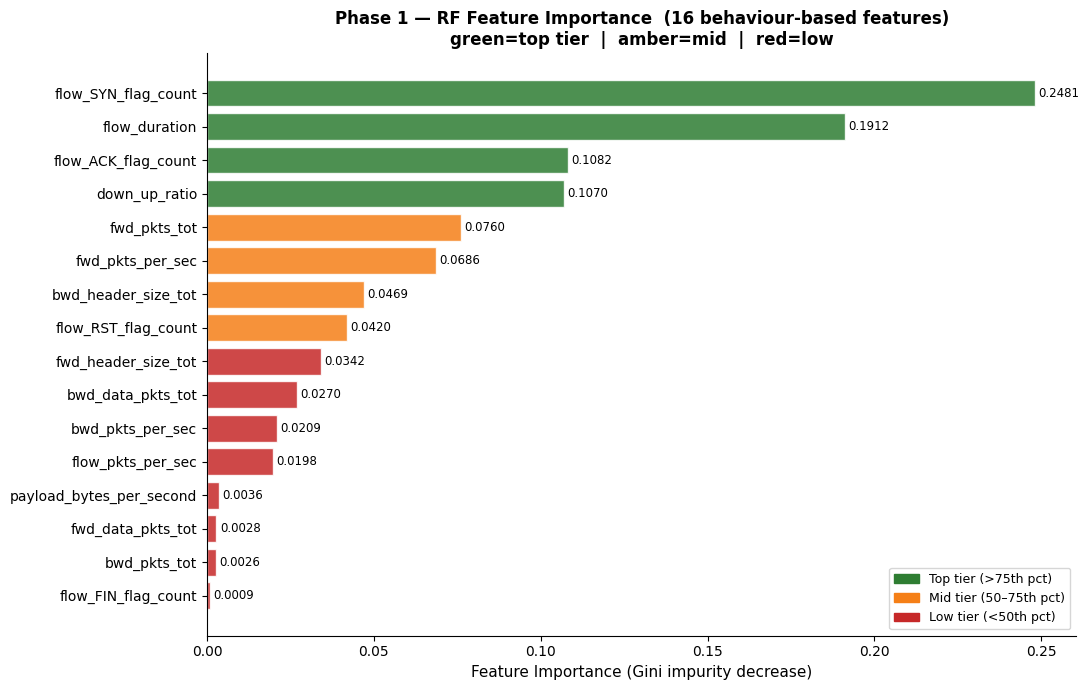

In [8]:
# ── Graph 1.4 — RF Feature Importance ────────────────────────────────────────
imp_p1 = p1_rf.feature_importances_
idx_p1 = np.argsort(imp_p1)
p75, p50 = np.percentile(imp_p1, 75), np.percentile(imp_p1, 50)
colors_fi = [PAL_OK   if imp_p1[i] >= p75 else
             PAL_WARN if imp_p1[i] >= p50 else
             PAL_BAD  for i in idx_p1]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(p1_feats)), imp_p1[idx_p1],
        color=colors_fi, alpha=0.85, edgecolor="white")
ax.set_yticks(range(len(p1_feats)))
ax.set_yticklabels([p1_feats[i] for i in idx_p1], fontsize=10)
ax.set_xlabel("Feature Importance (Gini impurity decrease)", fontsize=11)
ax.set_title(
    f"Phase 1 — RF Feature Importance  ({len(p1_feats)} behaviour-based features)\n"
    "green=top tier  |  amber=mid  |  red=low", **TITLE_KW)
for i, v in enumerate(imp_p1[idx_p1]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8.5)

patches_fi = [
    mpatches.Patch(color=PAL_OK,   label="Top tier (>75th pct)"),
    mpatches.Patch(color=PAL_WARN, label="Mid tier (50–75th pct)"),
    mpatches.Patch(color=PAL_BAD,  label="Low tier (<50th pct)"),
]
ax.legend(handles=patches_fi, fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 1.5 Confidence-Based Routing Distribution

The left chart shows how many flows were sorted into each bucket: clearly normal, clearly attack, or uncertain. Uncertain flows (orange band) are passed to Phase 3 rather than forced into a guess. The right chart shows the score distribution for normal vs attack flows. The more separated these two humps are, the cleaner the split.

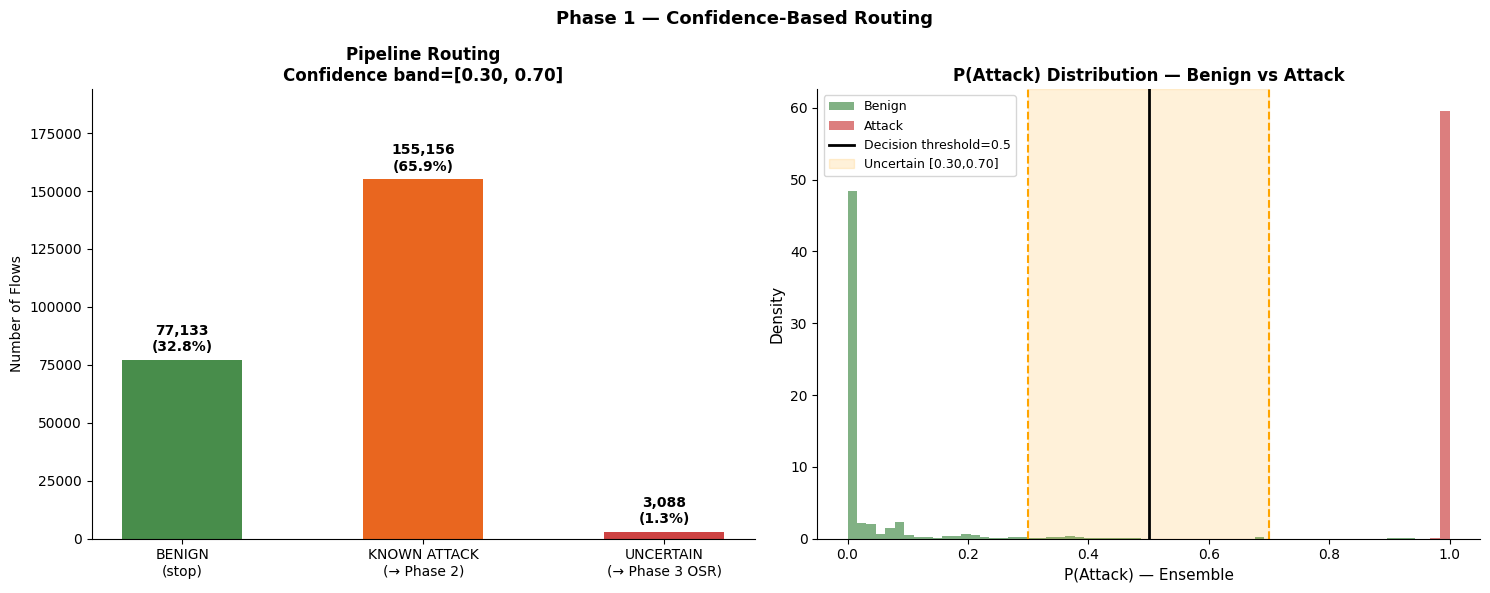

In [9]:
# ── Graph 1.5 — Confidence Routing Distribution ───────────────────────────────
routes_p1 = np.where(ens_prob_p1 <= P1_LOW_CONF,  "BENIGN",
            np.where(ens_prob_p1 >= P1_HIGH_CONF, "KNOWN_ATTACK", "UNCERTAIN"))
route_labels = ["BENIGN", "KNOWN_ATTACK", "UNCERTAIN"]
route_colors = [PAL_ENS, PAL_XGB, PAL_BAD]
sizes_p1 = [int((routes_p1 == r).sum()) for r in route_labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: routing bar
bars = ax1.bar(["BENIGN\n(stop)", "KNOWN ATTACK\n(→ Phase 2)",
                "UNCERTAIN\n(→ Phase 3 OSR)"],
               sizes_p1, color=route_colors, alpha=0.88, width=0.5)
for bar, n in zip(bars, sizes_p1):
    pct = 100 * n / max(sum(sizes_p1), 1)
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + sum(sizes_p1) * 0.010,
             f"{n:,}\n({pct:.1f}%)", ha="center", va="bottom",
             fontsize=10, fontweight="bold")
ax1.set_ylim(0, max(sizes_p1) * 1.25)
ax1.set_title(f"Pipeline Routing\nConfidence band=[{P1_LOW_CONF:.2f}, {P1_HIGH_CONF:.2f}]",
              **TITLE_KW)
ax1.set_ylabel("Number of Flows")
ax1.spines[["top", "right"]].set_visible(False)

# Right: probability density
ax2.hist(ens_prob_p1[y_test_p1 == 0], bins=60, alpha=0.6,
         color=PAL_ENS, label="Benign", density=True)
ax2.hist(ens_prob_p1[y_test_p1 == 1], bins=60, alpha=0.6,
         color=PAL_BAD, label="Attack", density=True)
ax2.axvline(0.5, color="black", lw=2, label="Decision threshold=0.5")
ax2.axvspan(P1_LOW_CONF, P1_HIGH_CONF, alpha=0.15, color="orange",
            label=f"Uncertain [{P1_LOW_CONF:.2f},{P1_HIGH_CONF:.2f}]")
ax2.axvline(P1_LOW_CONF,  color="orange", ls="--", lw=1.5)
ax2.axvline(P1_HIGH_CONF, color="orange", ls="--", lw=1.5)
ax2.set_xlabel("P(Attack) — Ensemble", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("P(Attack) Distribution — Benign vs Attack", **TITLE_KW)
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Phase 1 — Confidence-Based Routing", fontsize=13, **TITLE_KW)
plt.tight_layout()
plt.show()


---
## Phase 2 — Severity Classification

For flows already flagged as attacks, this phase sorts them into one of three severity tiers: Reconnaissance, Credential Abuse, or Active Exploitation.

In [10]:
# ── Phase 2 — A: Class stubs (required so joblib can unpickle saved artifacts) ─
class LabelCompressor:
    """Maps original class indices → compressed training indices and back."""
    def __init__(self, y_train, all_class_names):
        present = sorted(np.unique(y_train).tolist())
        self.orig_to_comp         = {orig: comp for comp, orig in enumerate(present)}
        self.comp_to_orig         = {comp: orig for comp, orig in enumerate(present)}
        self.n_train_classes      = len(present)
        self.train_class_names    = [all_class_names[i] for i in present]
        self.present_orig_indices = present

    def compress(self, y):
        return np.array([self.orig_to_comp[int(v)] for v in y], dtype=np.int8)

    def expand(self, y_comp):
        return np.array([self.comp_to_orig[int(v)] for v in y_comp], dtype=np.int8)

    def expand_proba(self, proba_comp, n_orig_classes):
        out = np.zeros((len(proba_comp), n_orig_classes), dtype=np.float32)
        for comp_idx, orig_idx in self.comp_to_orig.items():
            out[:, orig_idx] = proba_comp[:, comp_idx]
        return out


class EnsembleModelMulticlass:
    """Weighted soft-vote multiclass ensemble — mirrors training-script class."""
    def __init__(self, rf, xgb_clf, class_names, lc,
                 weights=(0.40, 0.60), confidence_min=0.70):
        self.rf             = rf
        self.xgb_clf        = xgb_clf
        self.class_names    = class_names
        self.lc             = lc
        self.weights        = weights
        self.confidence_min = confidence_min
        self.n_orig_classes = len(class_names)

    def predict_proba(self, X):
        p_c = (self.weights[0] * self.rf.predict_proba(X)
               + self.weights[1] * self.xgb_clf.predict_proba(X))
        return self.lc.expand_proba(p_c, self.n_orig_classes)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1).astype(np.int8)

    def confidence_route(self, X):
        proba     = self.predict_proba(X)
        max_probs = proba.max(axis=1)
        preds     = self.predict(X)
        routes    = []
        for p, max_p in zip(preds, max_probs):
            if max_p >= self.confidence_min:
                routes.append(self.class_names[int(p)])
            else:
                routes.append("UNCERTAIN")
        return routes, max_probs

print("✓ Phase 2 class stubs defined.")


✓ Phase 2 class stubs defined.


In [11]:
# ── Phase 2 — B: Load saved artifacts ────────────────────────────────────────
p2_rf      = joblib.load(os.path.join(P2_OUT, "model_rf.pkl"))
p2_xgb     = joblib.load(os.path.join(P2_OUT, "model_xgb.pkl"))
p2_ens     = joblib.load(os.path.join(P2_OUT, "model_ensemble.pkl"))
p2_scaler  = joblib.load(os.path.join(P2_OUT, "scaler.pkl"))
p2_imputer = joblib.load(os.path.join(P2_OUT, "imputer.pkl"))
p2_feats   = joblib.load(os.path.join(P2_OUT, "feature_names.pkl"))
p2_lc      = joblib.load(os.path.join(P2_OUT, "label_compressor.pkl"))
p2_split   = np.load(os.path.join(P2_OUT, "split_indices_mc.npz"))

with open(os.path.join(P2_OUT, "multiclass_metrics.json")) as f:
    p2_metrics_json = json.load(f)
p2_all_metrics = p2_metrics_json.get("models", [])

# Class schema — dynamic; never hardcoded
CLASS_NAMES = ["Reconnaissance", "Credential_Abuse", "Active_Exploitation"]
N_CLASSES   = len(CLASS_NAMES)

# Constants — must match threatmatrix_multiclass.py exactly
P2_RECON_CAP       = 100_000   # RECON_CAP in training script
P2_CALIB_VAL_RATIO = 0.15      # CALIB_VAL_RATIO in training script
P2_CONF_MIN        = getattr(p2_ens, "confidence_min", 0.70)
P2_TARGET_FILES    = {
    "web-ids23_portscan.csv"           : "Reconnaissance",
    "web-ids23_bruteforce_http.csv"    : "Credential_Abuse",
    "web-ids23_bruteforce_https.csv"   : "Credential_Abuse",
    "web-ids23_sql_injection_http.csv" : "Active_Exploitation",
    "web-ids23_sql_injection_https.csv": "Active_Exploitation",
}

print(f"✓ Phase 2 artifacts loaded — {len(p2_feats)} features  "
      f"confidence_min={P2_CONF_MIN:.3f}")
print(f"  Classes ({N_CLASSES}): {CLASS_NAMES}")


✓ Phase 2 artifacts loaded — 14 features  confidence_min=0.750
  Classes (3): ['Reconnaissance', 'Credential_Abuse', 'Active_Exploitation']


In [12]:
# ── Phase 2 — C: Reconstruct test set from CSVs + saved split indices ──────────
label_to_idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}

frames_p2 = []
for fname, lbl in P2_TARGET_FILES.items():
    path = os.path.join(DATASET_DIR, fname)
    if not os.path.exists(path):
        print(f"  [WARN] not found: {fname}")
        continue
    chunk = pd.read_csv(path, low_memory=False)
    chunk.columns = chunk.columns.str.strip()
    chunk["attack_type"] = lbl
    chunk["_src"]        = fname
    if lbl == "Reconnaissance" and len(chunk) > P2_RECON_CAP:
        chunk = chunk.sample(P2_RECON_CAP, random_state=42)
    frames_p2.append(chunk)

p2_df = pd.concat(frames_p2, ignore_index=True)
p2_df.drop_duplicates(inplace=True)
p2_df.reset_index(drop=True, inplace=True)

avail_p2  = [c for c in p2_feats if c in p2_df.columns]
X_p2_full = (p2_df[avail_p2]
             .replace([np.inf, -np.inf], np.nan)
             .astype(np.float32))
y_p2_full  = p2_df["attack_type"].map(label_to_idx).astype(np.int8).to_numpy()
src_p2     = p2_df["_src"].to_numpy()
p2_counts  = p2_df["attack_type"].value_counts()

X_p2_imp  = pd.DataFrame(p2_imputer.transform(X_p2_full), columns=avail_p2)
test_idx_p2  = p2_split["test_idx"]
train_idx_p2 = p2_split["train_idx"]

X_test_p2    = X_p2_imp.iloc[test_idx_p2].reset_index(drop=True).to_numpy(dtype=np.float32)
y_test_p2    = y_p2_full[test_idx_p2]
src_test_p2  = src_p2[test_idx_p2]
X_test_p2_sc = p2_scaler.transform(X_test_p2)

# Calib set (same deterministic split used during training, seed=42)
X_train_imp = X_p2_imp.iloc[train_idx_p2].to_numpy(dtype=np.float32)
y_train_p2  = y_p2_full[train_idx_p2]
_, X_calib_p2, _, y_calib_p2 = train_test_split(
    X_train_imp, y_train_p2,
    test_size=P2_CALIB_VAL_RATIO, stratify=y_train_p2, random_state=42)
X_calib_p2 = p2_scaler.transform(X_calib_p2)

# Probabilities — use LabelCompressor.expand_proba() (the real method on the saved object)
rf_prob_p2  = p2_lc.expand_proba(p2_rf.predict_proba(X_test_p2_sc),  N_CLASSES)
xgb_prob_p2 = p2_lc.expand_proba(p2_xgb.predict_proba(X_test_p2_sc), N_CLASSES)
ens_prob_p2 = ENS_W[0] * rf_prob_p2 + ENS_W[1] * xgb_prob_p2

# Predictions — use LabelCompressor.expand() to map compressed → original indices
rf_pred_p2  = p2_lc.expand(p2_rf.predict(X_test_p2_sc))
xgb_pred_p2 = p2_lc.expand(p2_xgb.predict(X_test_p2_sc))
ens_pred_p2 = p2_ens.predict(X_test_p2_sc)   # EnsembleModelMulticlass handles expansion internally

print(f"✓ Phase 2 test set ready — {len(y_test_p2):,} rows  Features={X_test_p2_sc.shape[1]}")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c}: {int((y_test_p2 == i).sum()):,}")


✓ Phase 2 test set ready — 410,903 rows  Features=14
  Reconnaissance: 20,000
  Credential_Abuse: 355,526
  Active_Exploitation: 35,377


### 2.1 Class Distribution

This chart shows how many samples are in each severity class, before and after balancing. The classes are not equal in size. Reconnaissance is by far the largest. The balanced version (right) shows the adjusted counts used for training.

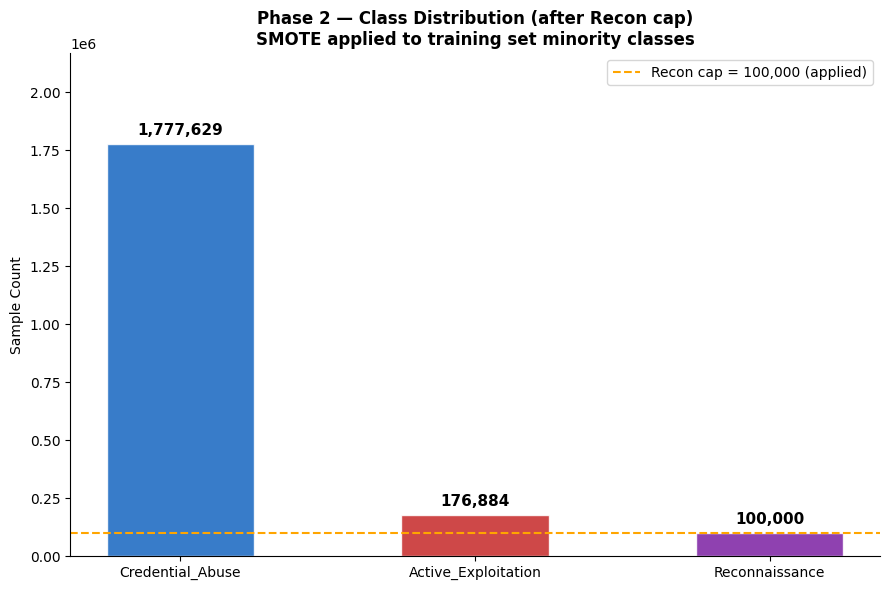

In [13]:
# ── Graph 2.1 — Class Distribution ───────────────────────────────────────────
cls_colors = {
    "Reconnaissance"     : "#7B1FA2",
    "Credential_Abuse"   : PAL_RF,
    "Active_Exploitation": PAL_BAD,
}
colors_cd = [cls_colors.get(k, "#9E9E9E") for k in p2_counts.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(p2_counts.index, p2_counts.values,
              color=colors_cd, alpha=0.85, edgecolor="white", width=0.5)
for bar, val in zip(bars, p2_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + p2_counts.max() * 0.015,
            f"{val:,}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.axhline(P2_RECON_CAP, color="orange", ls="--", lw=1.5,
           label=f"Recon cap = {P2_RECON_CAP:,} (applied)")
ax.set_ylim(0, p2_counts.max() * 1.22)
ax.set_title(
    "Phase 2 — Class Distribution (after Recon cap)\n"
    "SMOTE applied to training set minority classes", **TITLE_KW)
ax.set_ylabel("Sample Count")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 2.2 Three-Panel Confusion Matrices



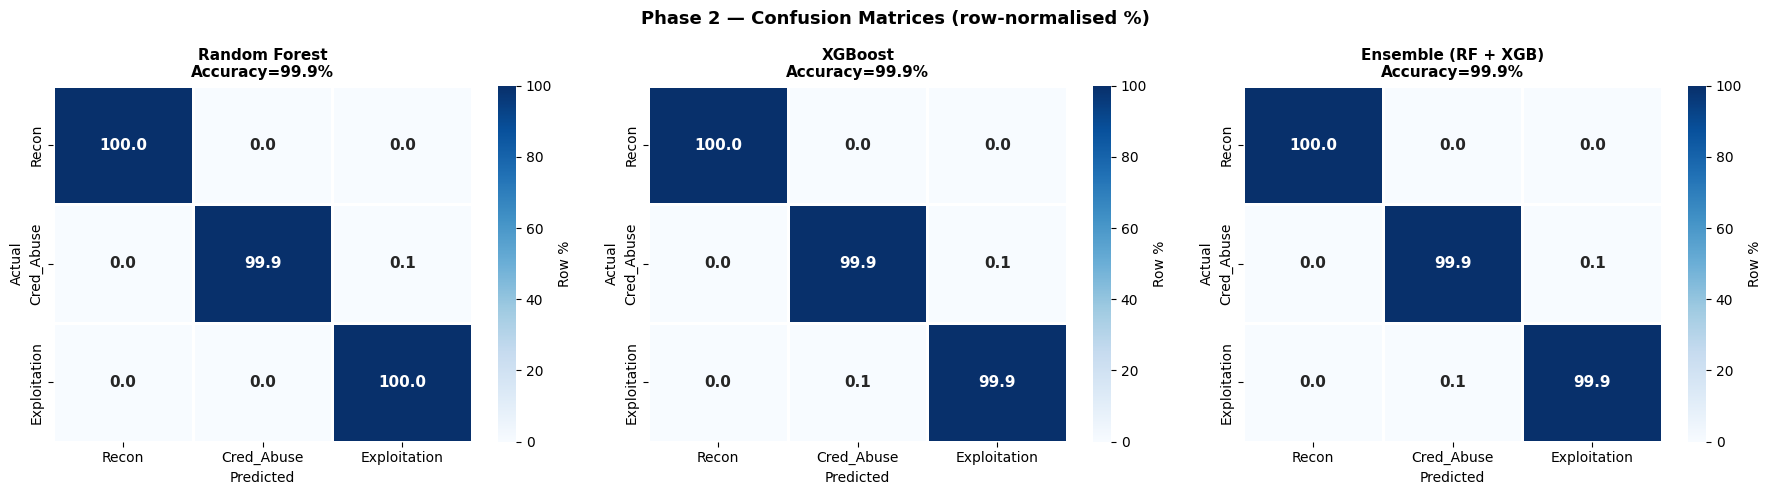

In [14]:
# ── Graph 2.2 — Three-Panel Confusion Matrices (row-normalised %) ─────────────
cls_short = ["Recon", "Cred_Abuse", "Exploitation"]
preds_dict = {
    "Random Forest"      : rf_pred_p2,
    "XGBoost"            : xgb_pred_p2,
    "Ensemble (RF + XGB)": ens_pred_p2,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (mname, pred) in zip(axes, preds_dict.items()):
    cm2     = confusion_matrix(y_test_p2, pred)
    cm2_pct = cm2.astype(float) / cm2.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm2_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=cls_short, yticklabels=cls_short,
                cbar_kws={"label": "Row %"},
                ax=ax, linewidths=0.8, linecolor="white",
                annot_kws={"size": 11, "weight": "bold"})
    acc = accuracy_score(y_test_p2, pred) * 100
    ax.set_title(f"{mname}\nAccuracy={acc:.1f}%", **TITLE_KW, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Phase 2 — Confusion Matrices (row-normalised %)", fontsize=13, **TITLE_KW)
plt.tight_layout()
plt.show()


### 2.3 Per-Class ROC (One-vs-Rest, Ensemble)

Instead of one overall score, this shows a separate ROC curve for each severity class. Each curve treats that class as 'yes' and all others as 'no'. A class with a lower curve is harder for the model to distinguish from the rest.

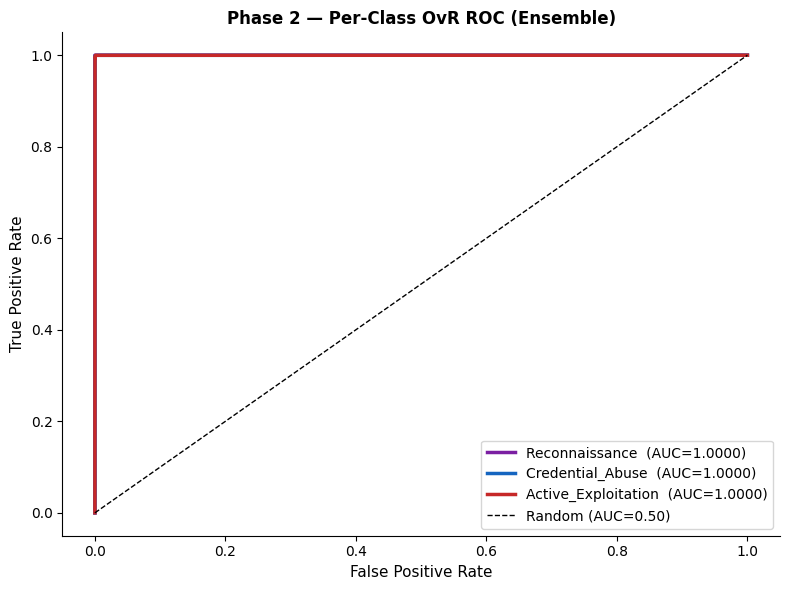

In [15]:
# ── Graph 2.3 — Per-Class OvR ROC (Ensemble) ─────────────────────────────────
ovr_colors = ["#7B1FA2", PAL_RF, PAL_BAD]

fig, ax = plt.subplots(figsize=(8, 6))
for i, (cname, col) in enumerate(zip(CLASS_NAMES, ovr_colors)):
    y_bin = (y_test_p2 == i).astype(int)
    if y_bin.sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin, ens_prob_p2[:, i])
    auc = roc_auc_score(y_bin, ens_prob_p2[:, i])
    ax.plot(fpr, tpr, color=col, lw=2.5, label=f"{cname}  (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.50)")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Phase 2 — Per-Class OvR ROC (Ensemble)", **TITLE_KW)
ax.legend(loc="lower right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 2.4 Radar Chart — Per-Class F1 Comparison

Each corner of the triangle represents one severity class. Each model's shape shows how well it scored on that class — a larger filled area means better overall balance. If one corner is noticeably smaller, that class is weaker for that model.

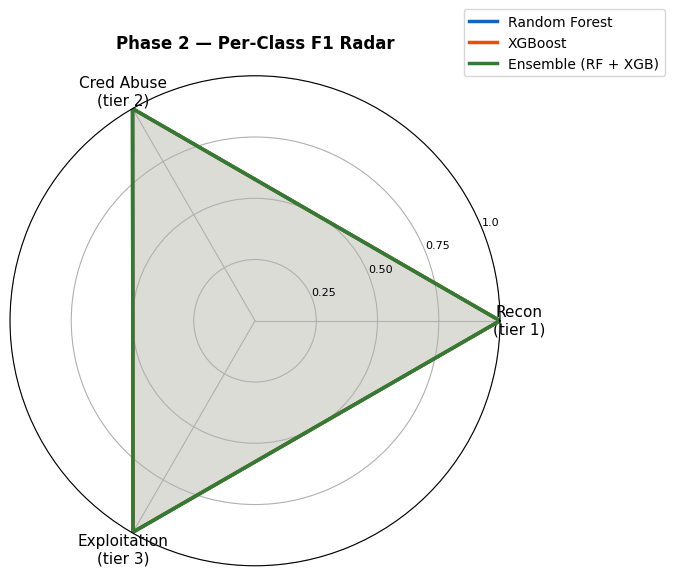

In [16]:
# ── Graph 2.4 — Radar Chart: Per-Class F1 ────────────────────────────────────
def _per_class_f1(y_true, y_pred, n_classes):
    return [f1_score(y_true == i, y_pred == i, zero_division=0)
            for i in range(n_classes)]

angles = np.linspace(0, 2 * np.pi, N_CLASSES, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for (mname, pred), col in zip(preds_dict.items(), [PAL_RF, PAL_XGB, PAL_ENS]):
    vals = _per_class_f1(y_test_p2, pred, N_CLASSES) +            [_per_class_f1(y_test_p2, pred, N_CLASSES)[0]]
    ax.plot(angles, vals, color=col, lw=2.5, label=mname)
    ax.fill(angles, vals, color=col, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    ["Recon\n(tier 1)", "Cred Abuse\n(tier 2)", "Exploitation\n(tier 3)"],
    fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], fontsize=8)
ax.set_title("Phase 2 — Per-Class F1 Radar", **TITLE_KW, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()


### 2.5 Cross-Subtype Generalisation (HTTP and HTTPS)

This tests whether the model can handle the same attack type over a different protocol. For example, training on HTTP brute-force and testing on HTTPS brute-force. High accuracy here means the model learned the attack pattern, not just the protocol details.

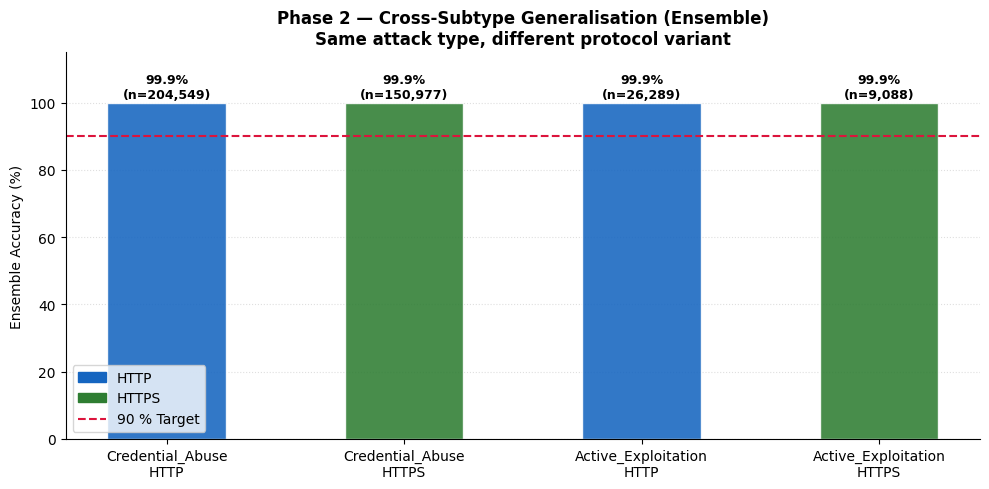

In [17]:
# ── Graph 2.5 — Cross-Subtype Generalisation (HTTP ↔ HTTPS) ──────────────────
src_map = {
    "web-ids23_bruteforce_http.csv"    : ("Credential_Abuse",    "HTTP"),
    "web-ids23_bruteforce_https.csv"   : ("Credential_Abuse",    "HTTPS"),
    "web-ids23_sql_injection_http.csv" : ("Active_Exploitation",  "HTTP"),
    "web-ids23_sql_injection_https.csv": ("Active_Exploitation",  "HTTPS"),
}

results_cs = []
for src_file, (cls_name, protocol) in src_map.items():
    mask = src_test_p2 == src_file
    if mask.sum() < 10:
        continue
    cls_idx = label_to_idx[cls_name]
    acc = accuracy_score(y_test_p2[mask], ens_pred_p2[mask]) * 100
    results_cs.append({"Source": f"{cls_name}\n{protocol}",
                        "Accuracy": acc, "N": mask.sum(), "Protocol": protocol})

df_cs = pd.DataFrame(results_cs)
colors_cs = [PAL_RF if r["Protocol"] == "HTTP" else PAL_ENS
             for _, r in df_cs.iterrows()]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_cs["Source"], df_cs["Accuracy"],
              color=colors_cs, alpha=0.88, edgecolor="white", width=0.5)
for bar, (_, row) in zip(bars, df_cs.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{row['Accuracy']:.1f}%\n(n={row['N']:,})",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(90, color="crimson", ls="--", lw=1.5, label="90 % Target")
ax.set_ylim(0, 115)
ax.set_ylabel("Ensemble Accuracy (%)")
ax.yaxis.grid(True, alpha=0.4, linestyle=":")
ax.set_title(
    "Phase 2 — Cross-Subtype Generalisation (Ensemble)\n"
    "Same attack type, different protocol variant", **TITLE_KW)
patches_cs = [mpatches.Patch(color=PAL_RF,  label="HTTP"),
              mpatches.Patch(color=PAL_ENS, label="HTTPS")]
ax.legend(
    handles=patches_cs + [plt.Line2D([0],[0], color="crimson", ls="--",
                                     lw=1.5, label="90 % Target")],
    fontsize=10)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 2.6 Confidence Routing Breakdown

For each severity class, this shows what fraction of its samples the ensemble was confident about vs uncertain. Confident predictions (coloured bars) stay in Phase 2. Uncertain ones (grey bars) are sent to Phase 3. A high grey bar on any class means the model struggles with that tier.

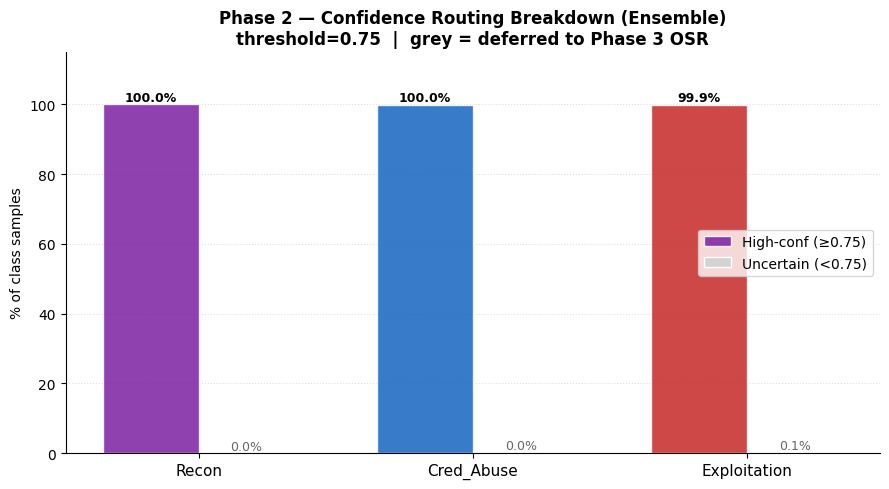

In [18]:
# ── Graph 2.6 — Confidence Routing Breakdown ─────────────────────────────────
ens_max_conf = ens_prob_p2.max(axis=1)
ovr_colors   = ["#7B1FA2", PAL_RF, PAL_BAD]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(N_CLASSES)
w = 0.35
for i, (cname, col) in enumerate(zip(CLASS_NAMES, ovr_colors)):
    mask    = y_test_p2 == i
    if mask.sum() == 0:
        continue
    c_above = (ens_max_conf[mask] >= P2_CONF_MIN).mean() * 100
    c_below = 100 - c_above
    ax.bar(i - w / 2, c_above, w, color=col, alpha=0.85, edgecolor="white",
           label=f"High-conf (≥{P2_CONF_MIN:.2f})" if i == 0 else "")
    ax.bar(i + w / 2, c_below, w, color="lightgrey", edgecolor="white",
           label=f"Uncertain (<{P2_CONF_MIN:.2f})"  if i == 0 else "")
    ax.text(i - w / 2, c_above + 1, f"{c_above:.1f}%",
            ha="center", fontsize=9, fontweight="bold")
    ax.text(i + w / 2, c_below + 1, f"{c_below:.1f}%",
            ha="center", fontsize=9, color="#666")

ax.set_xticks(x)
ax.set_xticklabels(["Recon", "Cred_Abuse", "Exploitation"], fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel("% of class samples")
ax.yaxis.grid(True, alpha=0.4, linestyle=":")
ax.set_title(
    f"Phase 2 — Confidence Routing Breakdown (Ensemble)\n"
    f"threshold={P2_CONF_MIN:.2f}  |  grey = deferred to Phase 3 OSR", **TITLE_KW)
ax.legend(fontsize=10)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


---
## Phase 3 — Open-Set Recognition

This phase handles flows the earlier phases are unsure about. It classifies known attack types and also flags traffic from attack types it was never trained on (novel attacks). Two detection methods are compared: Max-Softmax and Mahalanobis-on-leaves.

In [19]:
# ── Phase 3 — A: Class stubs (required so joblib can unpickle saved artifacts) ─
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.impute        import SimpleImputer

class TreePreprocessor:
    """Imputer → RobustScaler — mirrors the training-script class exactly."""
    def __init__(self, feature_names):
        self.feature_names = list(feature_names)
        self.imputer       = SimpleImputer(strategy="median")
        self.scaler        = RobustScaler(quantile_range=(5.0, 95.0))

    def _select(self, df):
        import pandas as pd
        miss = [c for c in self.feature_names if c not in df.columns]
        for c in miss:
            df[c] = np.nan
        X = df[self.feature_names].copy()
        X.replace([np.inf, -np.inf], np.nan, inplace=True)
        return X.astype(np.float64).to_numpy()

    def fit_transform(self, df):
        X = self.imputer.fit_transform(self._select(df))
        return self.scaler.fit_transform(X).astype(np.float32)

    def transform(self, df):
        if df is None or len(df) == 0:
            return np.empty((0, len(self.feature_names)), dtype=np.float32), 0
        X     = self._select(df)
        n_nan = int(np.isnan(X).sum())
        X = self.imputer.transform(X)
        X = self.scaler.transform(X)
        return X.astype(np.float32), n_nan


class OpenSetClassifier:
    """RF + dual OSR (max-softmax + Mahalanobis-on-leaves)."""
    def __init__(self, rf, class_names, feature_names,
                 leaf_pca, leaf_class_means, leaf_class_inv_covs,
                 thr_softmax, thr_maha, calibration_metadata=None):
        self.rf                  = rf
        self.class_names         = list(class_names)
        self.feature_names       = list(feature_names)
        self.leaf_pca            = leaf_pca
        self.leaf_class_means    = {c: np.asarray(mu, dtype=np.float64)
                                    for c, mu in leaf_class_means.items()}
        self.leaf_class_inv_covs = {c: np.asarray(v,  dtype=np.float64)
                                    for c, v  in leaf_class_inv_covs.items()}
        self.thr_softmax          = float(thr_softmax)
        self.thr_maha             = float(thr_maha)
        self.calibration_metadata = calibration_metadata or {}

    def _leaf_embed(self, X):
        leaves = self.rf.apply(X)
        return self.leaf_pca.transform(leaves.astype(np.float32))

    def softmax_ood_score(self, X):
        return 1.0 - self.rf.predict_proba(X).max(axis=1)

    def mahalanobis_ood_score(self, X):
        emb   = self._leaf_embed(X).astype(np.float64)
        n     = emb.shape[0]
        dists = np.full((n, len(self.class_names)), np.inf, dtype=np.float64)
        for ci, cname in enumerate(self.class_names):
            if cname not in self.leaf_class_means:
                continue
            mu  = self.leaf_class_means[cname]
            inv = self.leaf_class_inv_covs[cname]
            d   = emb - mu
            dists[:, ci] = np.sqrt(
                np.einsum("ij,jk,ik->i", d, inv, d).clip(min=0))
        return dists.min(axis=1).astype(np.float32)

    def predict_proba(self, X):
        return self.rf.predict_proba(X)

    def predict(self, X):
        return self.rf.predict(X)

print("✓ Phase 3 class stubs defined.")


✓ Phase 3 class stubs defined.


In [20]:
# ── Phase 3 — B: Load saved artifacts ────────────────────────────────────────
p3_model = joblib.load(os.path.join(P3_OUT, "model_anomaly_detector.pkl"))
p3_pre   = joblib.load(os.path.join(P3_OUT, "preprocessor_phase3.pkl"))

with open(os.path.join(P3_OUT, "phase3_metrics.json")) as f:
    p3_m = json.load(f)

# JSON structure from training script
closed_metrics  = p3_m["closed_world_metrics"]
osr_results     = p3_m["open_world_metrics"]
p3_class_names  = p3_m["architecture"]["class_names"]
p3_feat_names   = p3_m["architecture"]["feature_names"]
shap_data       = p3_m.get("shap_feature_importance")

# OSR method references (standardised keys)
_SOFT = "max_softmax"
_MAHA = "mahalanobis_leaves"

P3_NOVEL_FILE_LIST = [
    ("web-ids23_revshell_http.csv",        "RevShell HTTP",  "RevShell"),
    ("web-ids23_revshell_https.csv",       "RevShell HTTPS", "RevShell"),
    ("web-ids23_xss_http.csv",             "XSS HTTP",       "XSS"),
    ("web-ids23_xss_https.csv",            "XSS HTTPS",      "XSS"),
    ("web-ids23_ssrf_http.csv",            "SSRF HTTP",      "SSRF"),
    ("web-ids23_ssrf_https.csv",           "SSRF HTTPS",     "SSRF"),
    ("web-ids23_ssh_login_successful.csv", "SSH Login",       "SSH_Login"),
]

print(f"✓ Phase 3 artifacts loaded")
print(f"  Known classes ({len(p3_class_names)}): {p3_class_names}")
print(f"  Features: {len(p3_feat_names)}")
print(f"  Closed-world accuracy : {closed_metrics['accuracy']*100:.2f}%")
print(f"  Closed-world macro-F1 : {closed_metrics['macro_f1']*100:.2f}%")
print(f"  Softmax  AUROC: {osr_results[_SOFT]['auroc']:.4f}  "
      f"  Maha AUROC: {osr_results[_MAHA]['auroc']:.4f}")


✓ Phase 3 artifacts loaded
  Known classes (6): ['Benign', 'Portscan', 'BruteForce_HTTP', 'BruteForce_HTTPS', 'SQLi_HTTP', 'SQLi_HTTPS']
  Features: 14
  Closed-world accuracy : 99.27%
  Closed-world macro-F1 : 98.92%
  Softmax  AUROC: 0.9503    Maha AUROC: 0.9137


### 3.1 Closed-World Confusion Matrix

This shows how well the model classifies the 6 known classes when only those classes are present. The diagonal shows correct predictions. This is the baseline before novel detection is added on top.

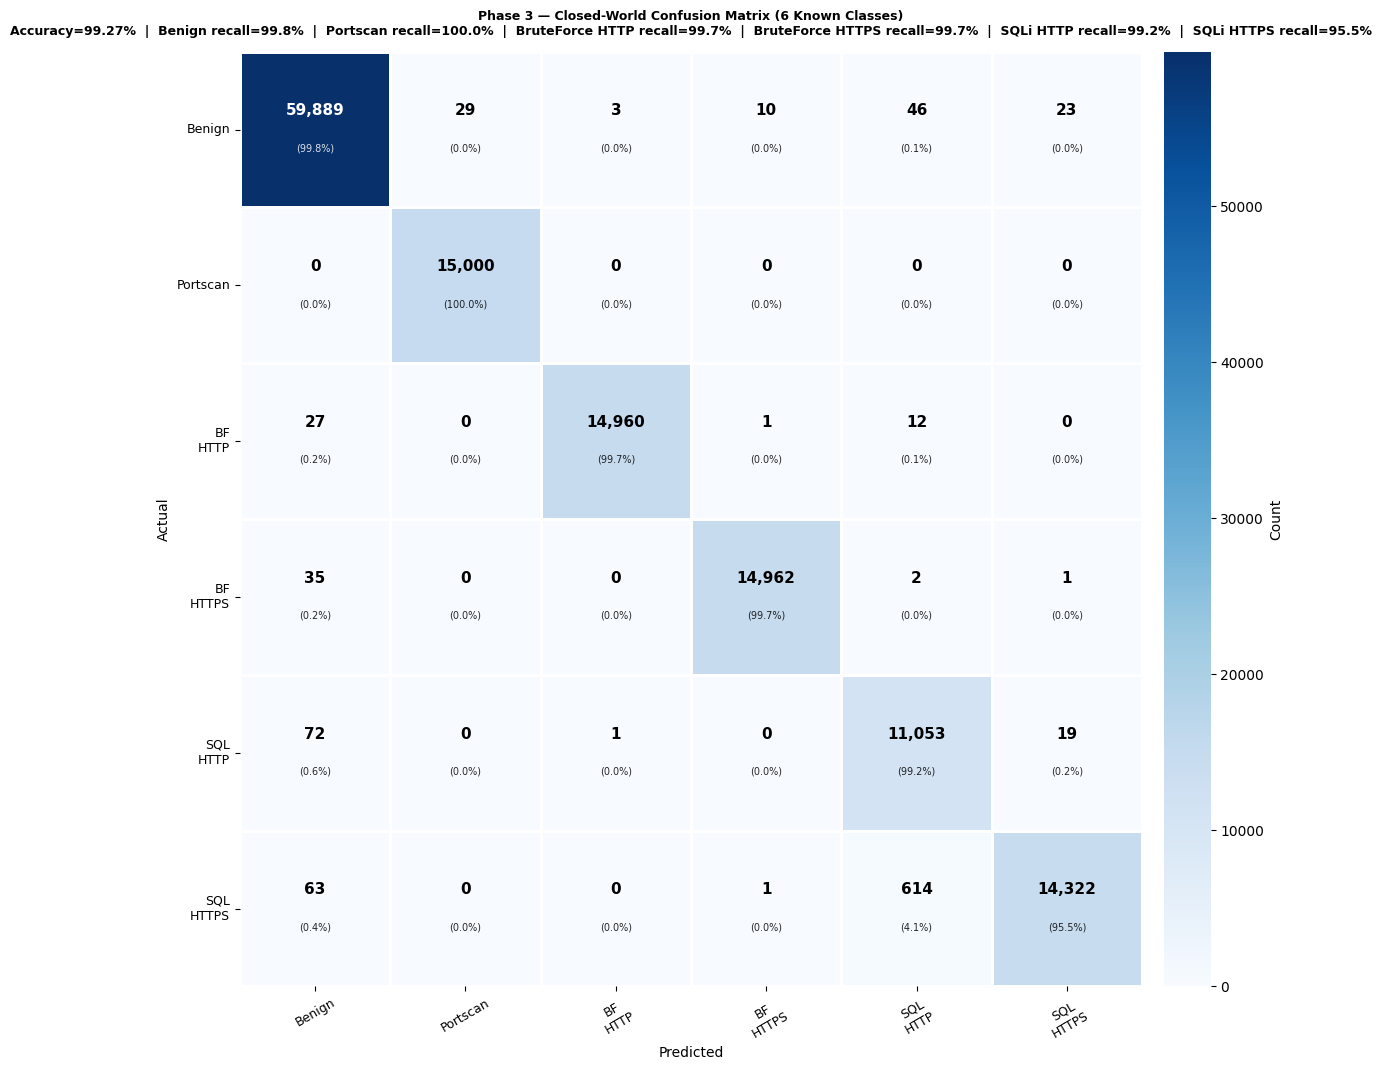

In [21]:
# ── Graph 3.1 — Closed-World Confusion Matrix (6 known classes) ───────────────
cm_p3     = np.array(closed_metrics["confusion_matrix"])
n_cls_p3  = len(p3_class_names)
cm_p3_pct = (cm_p3.astype(float) /
             np.maximum(cm_p3.sum(axis=1, keepdims=True), 1) * 100)
short_p3  = [c.replace("BruteForce_", "BF_").replace("SQLi_", "SQL_").replace("_", "\n")
             for c in p3_class_names]

fig, ax = plt.subplots(figsize=(max(8, n_cls_p3 * 2.0), max(7, n_cls_p3 * 1.8)))
sns.heatmap(cm_p3, annot=False, cmap="Blues", ax=ax,
            xticklabels=short_p3, yticklabels=short_p3,
            cbar_kws={"label": "Count", "pad": 0.02},
            linewidths=1.0, linecolor="white")
thr_p3 = cm_p3.max() * 0.5
for i in range(n_cls_p3):
    for j in range(n_cls_p3):
        c = "white" if cm_p3[i, j] > thr_p3 else "black"
        ax.text(j + 0.5, i + 0.38, f"{cm_p3[i,j]:,}",
                ha="center", va="center",
                fontsize=11, fontweight="bold", color=c)
        ax.text(j + 0.5, i + 0.62, f"({cm_p3_pct[i,j]:.1f}%)",
                ha="center", va="center",
                fontsize=7, color=c, alpha=0.85)

recall_str = "  |  ".join(
    f"{p3_class_names[i].replace('_',' ')} recall={cm_p3_pct[i,i]:.1f}%"
    for i in range(n_cls_p3))
ax.set_title(
    f"Phase 3 — Closed-World Confusion Matrix ({n_cls_p3} Known Classes)\n"
    f"Accuracy={closed_metrics['accuracy']*100:.2f}%  |  {recall_str}",
    **TITLE_KW, fontsize=9, pad=12)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()


### 3.2 Score Distributions — Known vs Novel

Each chart shows the score spread for known traffic (green) vs novel attacks (red) for one detection method. Where the two curves overlap, the model is less certain. The dashed line is the decision threshold, everything to the right gets flagged as novel.

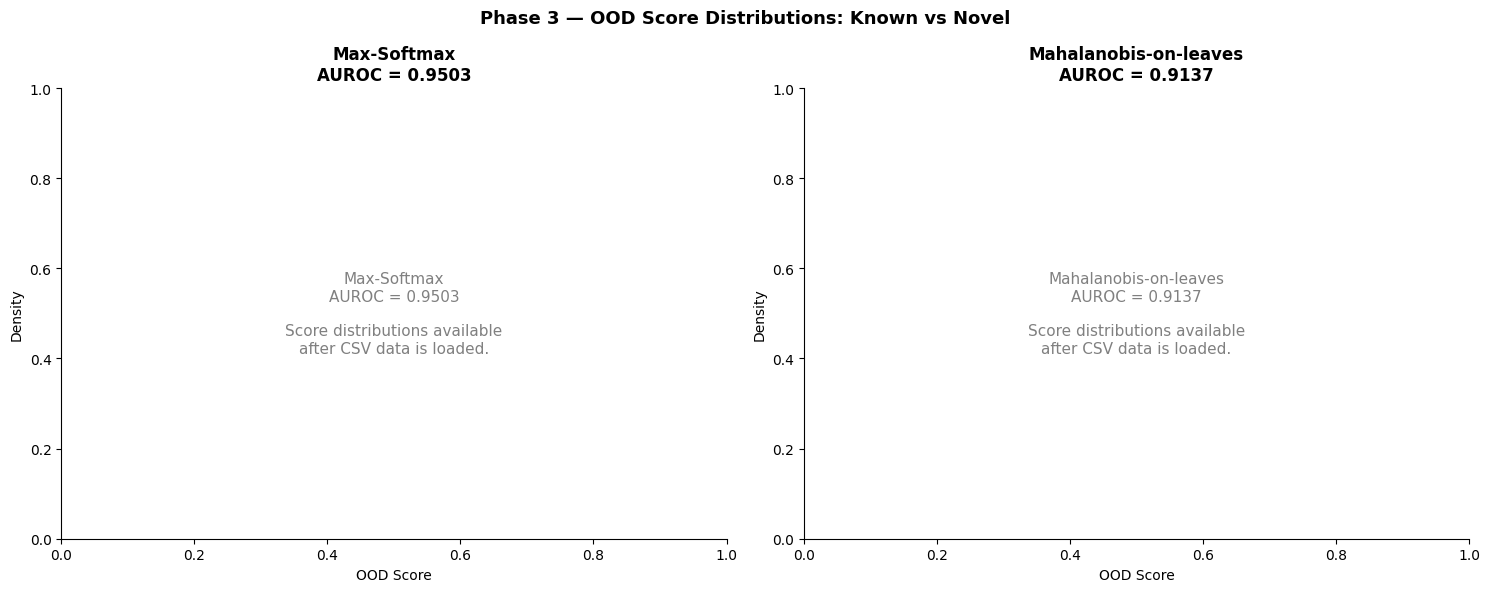

In [22]:
# ── Graph 3.2 — OSR Score Distributions (KDE) ────────────────────────────────
from scipy.stats import gaussian_kde

_pretty = {_SOFT: "Max-Softmax", _MAHA: "Mahalanobis-on-leaves"}
_has_scores = all(
    "scores_known_sample" in osr_results[m] and
    "scores_novel_sample" in osr_results[m]
    for m in (_SOFT, _MAHA))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, method in zip(axes, [_SOFT, _MAHA]):
    res   = osr_results[method]
    label = _pretty[method]
    auroc = res["auroc"]
    thr   = res["threshold"]

    if _has_scores:
        s_k = np.array(res["scores_known_sample"])
        s_n = np.array(res["scores_novel_sample"])
        lo  = min(s_k.min(), s_n.min())
        hi  = max(np.percentile(s_k, 99), np.percentile(s_n, 99))
        xg  = np.linspace(lo, hi, 600)

        for scores, col, lbl in [(s_k, PAL_ENS, f"Known  (n={len(s_k):,})"),
                                  (s_n, PAL_BAD, f"Novel  (n={len(s_n):,})")]:
            sc = np.clip(scores, lo, hi)
            if sc.std() < 1e-10:
                continue
            density = gaussian_kde(sc, bw_method="scott")(xg)
            ax.plot(xg, density, color=col, lw=2.2, label=lbl)
            ax.fill_between(xg, density, alpha=0.15, color=col)

        ax.axvline(thr, color="crimson", ls="--", lw=2.0,
                   label=f"Threshold={thr:.4f}")
        ax.set_xlim(lo, hi)
        ax.set_xlabel("OOD Score")
        ax.set_ylabel("Density")
        ax.legend(loc="upper right", fontsize=9)
    else:
        ax.text(0.5, 0.5,
                f"{label}\nAUROC = {auroc:.4f}\n\n"
                "Score distributions available\nafter CSV data is loaded.",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=11, color="gray")
        ax.set_xlabel("OOD Score")
        ax.set_ylabel("Density")

    ax.set_title(f"{label}\nAUROC = {auroc:.4f}", **TITLE_KW)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Phase 3 — OOD Score Distributions: Known vs Novel", fontsize=13, **TITLE_KW)
plt.tight_layout()
plt.show()


### 3.3 Detection ROC — Max-Softmax vs Mahalanobis

This compares the two detection methods head-to-head. The curve closer to the top-left corner catches more novel attacks with fewer false flags on known traffic. AUROC is the summary score — higher is better.

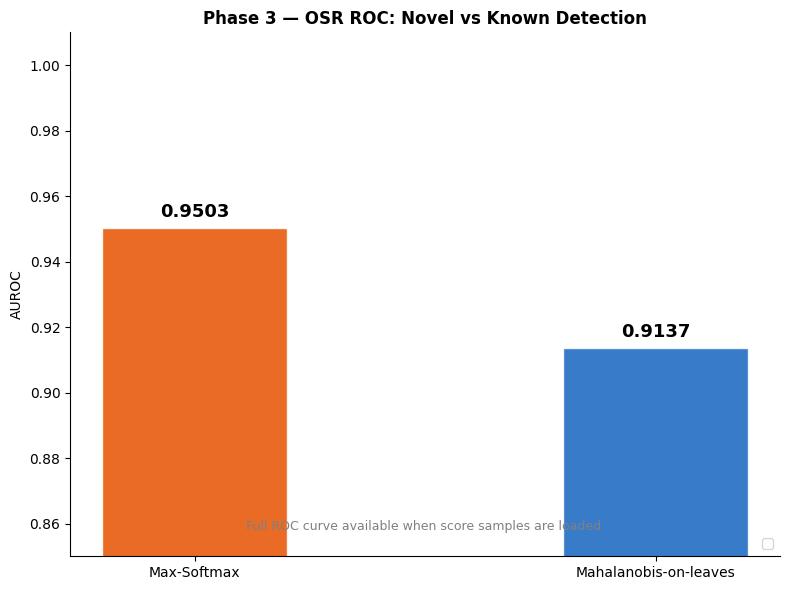

In [23]:
# ── Graph 3.3 — OSR ROC Comparison ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

if _has_scores:
    for method, col in [(_SOFT, PAL_XGB), (_MAHA, PAL_RF)]:
        res   = osr_results[method]
        s_k   = np.array(res["scores_known_sample"])
        s_n   = np.array(res["scores_novel_sample"])
        y_osr = np.r_[np.zeros(len(s_k)), np.ones(len(s_n))]
        fpr, tpr, _ = roc_curve(y_osr, np.r_[s_k, s_n])
        auroc = roc_auc_score(y_osr, np.r_[s_k, s_n])
        ax.plot(fpr, tpr, color=col, lw=2.5,
                label=f"{_pretty[method]}  (AUROC={auroc:.4f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUROC=0.50)")
    ax.set_xlabel("False Positive Rate (known flagged as novel)", fontsize=11)
    ax.set_ylabel("True Positive Rate (novel detected)", fontsize=11)
else:
    # Fall back to bar chart of stored AUROC values
    methods = [_SOFT, _MAHA]
    aurocs  = [osr_results[m]["auroc"] for m in methods]
    bars = ax.bar([_pretty[m] for m in methods], aurocs,
                  color=[PAL_XGB, PAL_RF], alpha=0.85, edgecolor="white", width=0.4)
    for bar, v in zip(bars, aurocs):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002,
                f"{v:.4f}", ha="center", va="bottom",
                fontsize=13, fontweight="bold")
    ax.set_ylim(0.85, 1.01)
    ax.set_ylabel("AUROC")
    ax.text(0.5, 0.05, "Full ROC curve available when score samples are loaded.",
            ha="center", transform=ax.transAxes, fontsize=9, color="gray")

ax.set_title("Phase 3 — OSR ROC: Novel vs Known Detection", **TITLE_KW)
ax.legend(loc="lower right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 3.4 Per-Novel-Source Detection Rate

This shows how well the model detected each individual novel attack type it was never trained on. Longer bars mean more of those flows were correctly flagged. Some attack types are harder to spot because their traffic patterns look similar to known normal or attack traffic.

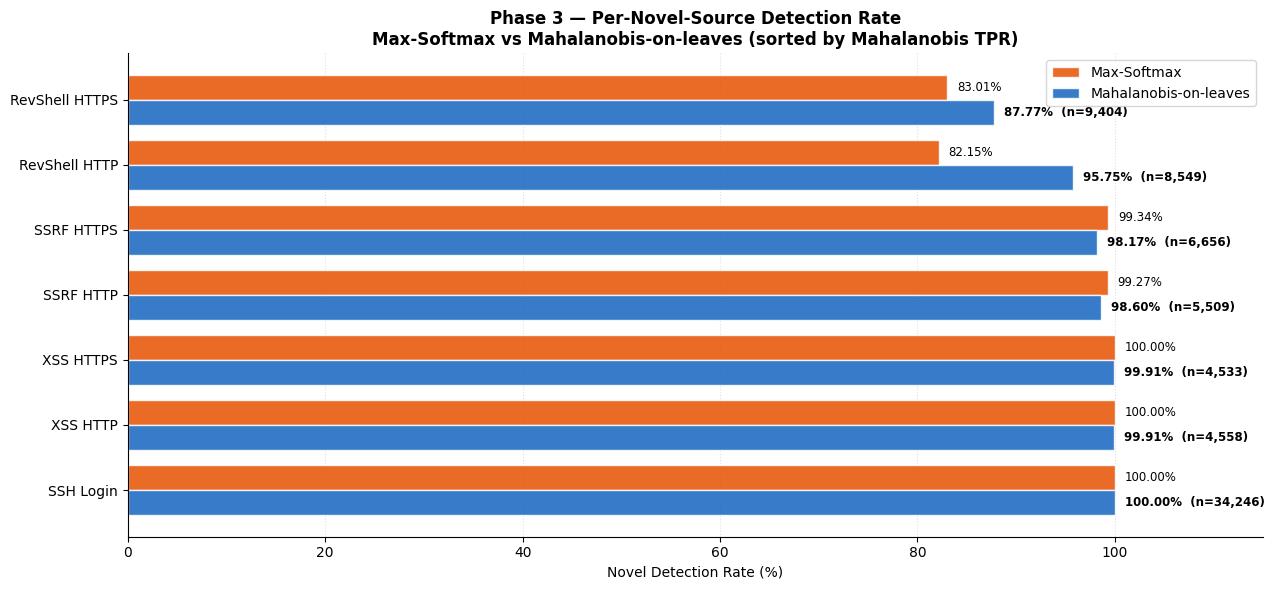

In [24]:
# ── Graph 3.4 — Per-Novel-Source Detection Rate ───────────────────────────────
# Pull per-source TPR from JSON (stored during training)
all_sources   = sorted(
    {s for m in (_SOFT, _MAHA)
       for s in osr_results[m]["per_novel_source"]},
    key=lambda s: osr_results[_MAHA]["per_novel_source"][s]["tpr"])

# Build display labels: prefer P3_NOVEL_FILE_LIST; fall back to raw key
fname_to_label = {fname: disp for fname, disp, _ in P3_NOVEL_FILE_LIST}
disp_labels    = [fname_to_label.get(s, s) for s in all_sources]
soft_tprs = [osr_results[_SOFT]["per_novel_source"][s]["tpr"] * 100
             for s in all_sources]
maha_tprs = [osr_results[_MAHA]["per_novel_source"][s]["tpr"] * 100
             for s in all_sources]
counts    = [osr_results[_MAHA]["per_novel_source"][s]["n"]
             for s in all_sources]

n_src = len(all_sources)
y_src = np.arange(n_src)
h     = 0.38

fig, ax = plt.subplots(figsize=(13, max(6, n_src * 0.85)))
bars_s = ax.barh(y_src - h / 2, soft_tprs, h,
                 color=PAL_XGB, alpha=0.85, edgecolor="white",
                 label="Max-Softmax")
bars_m = ax.barh(y_src + h / 2, maha_tprs, h,
                 color=PAL_RF,  alpha=0.85, edgecolor="white",
                 label="Mahalanobis-on-leaves")

for bar, v in zip(bars_s, soft_tprs):
    ax.text(min(v + 1, 102), bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}%", va="center", fontsize=8.5)
for bar, v, n in zip(bars_m, maha_tprs, counts):
    ax.text(min(v + 1, 102), bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}%  (n={n:,})", va="center",
            fontsize=8.5, fontweight="bold")

ax.set_yticks(y_src)
ax.set_yticklabels(disp_labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 115)
ax.set_xlabel("Novel Detection Rate (%)")
ax.set_title(
    "Phase 3 — Per-Novel-Source Detection Rate\n"
    "Max-Softmax vs Mahalanobis-on-leaves (sorted by Mahalanobis TPR)",
    **TITLE_KW)
ax.xaxis.grid(True, alpha=0.4, linestyle=":")
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


---
## Cross-Phase Summary

The table below summarises the key result from each phase in one place.

In [25]:
# ── Cross-Phase Summary Table ─────────────────────────────────────────────────
# Pull key scores dynamically from already-computed variables

# Phase 1: ensemble recall
_p1_ens = next((m for m in p1_all_metrics if "Ensemble" in m["name"]),
               p1_all_metrics[-1] if p1_all_metrics else {})

# Phase 2: ensemble macro-F1 (from JSON or recomputed)
_p2_macro_f1 = p2_metrics_json.get("ensemble_macro_f1")
if _p2_macro_f1 is None and p2_all_metrics:
    _last = p2_all_metrics[-1]
    _p2_macro_f1 = _last.get("macro_f1", _last.get("f1", 0))

# Phase 3: Mahalanobis AUROC (better detector)
_p3_auroc = osr_results[_MAHA]["auroc"]

summary = [
    {
        "Phase"      : "Phase 1 — Binary",
        "Models"     : "RF + XGB + Ensemble",
        "Classes"    : "Benign / Attack",
        "Key Metric" : "Recall",
        "Score"      : f"{_p1_ens.get('recall', 0) * 100:.2f}%" if _p1_ens else "—",
    },
    {
        "Phase"      : "Phase 2 — Multiclass",
        "Models"     : "RF + XGB + Ensemble",
        "Classes"    : "Recon / Cred_Abuse / Exploitation",
        "Key Metric" : "Macro-F1",
        "Score"      : f"{_p2_macro_f1 * 100:.2f}%" if _p2_macro_f1 else "—",
    },
    {
        "Phase"      : "Phase 3 — Open-Set",
        "Models"     : "RF + Max-Softmax + Mahalanobis",
        "Classes"    : f"{len(p3_class_names)} known + novel detection",
        "Key Metric" : "AUROC (novel vs known)",
        "Score"      : f"{_p3_auroc * 100:.2f}%",
    },
]

df_summary = pd.DataFrame(summary).set_index("Phase")
display(df_summary)


,Models,Classes,Key Metric,Score
Phase,,,,
Phase 1 — Binary,RF + XGB + Ensemble,Benign / Attack,Recall,99.74%
Phase 2 — Multiclass,RF + XGB + Ensemble,Recon / Cred_Abuse / Exploitation,Macro-F1,99.85%
Phase 3 — Open-Set,RF + Max-Softmax + Mahalanobis,6 known + novel detection,AUROC (novel vs known),91.37%
